# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abdelrahmanmohamed05/FlyRank-AI/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question:** Can we rank content that is likely to under-capture clicks in the next month, using only information available before that month?

**Decision supported:** give a content/SEO team a ranked queue for CTR review, so limited review time can start with pages that already have meaningful search visibility but show weaker click-through performance.

**Lane:** CTR / Engagement Opportunity Scoring.

The analysis is intentionally decision-support, not a causal claim about Google's ranking system. The final output is a ranked review queue with one action and one reason code per row.

In [1]:

# Setup: connect to the gated FlyRank warehouse.
# Put HF_TOKEN in the Colab Secret/environment; never paste the token into this notebook.
import os
import getpass
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

def get_hf_token():
    # Colab Secret first
    try:
        from google.colab import userdata
        tok = userdata.get("HF_TOKEN")
        if tok:
            return tok
    except Exception:
        pass

    tok = os.environ.get("HF_TOKEN")
    if tok:
        return tok

    return getpass.getpass("Hugging Face READ token: ")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

token = get_hf_token().replace("'", "''")
con.execute(f"SET VARIABLE hf_token = '{token}'")
con.execute(
    "CREATE OR REPLACE SECRET hf "
    "(TYPE huggingface, TOKEN getvariable('hf_token'))"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

OUTPUT_DIR = "work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Connected to the FlyRank warehouse.")
print("Feature window: 2026-02")
print("Outcome window: 2026-03")


Connected to the FlyRank warehouse.
Feature window: 2026-02
Outcome window: 2026-03


## 2. Data

This notebook uses the FlyRank internship warehouse on Hugging Face.

**Feature window:** February 2026.  
**Outcome window:** March 2026.  
**Excluded:** the `_sample` partition, future March fields from the feature set, query-level outcome data, and any client/domain/query identifiers that are not needed for the public analysis.

The main source is `fact_content_daily_performance`, aggregated to `client_hash_id × content_hash_id`. We use GSC impressions, GSC clicks, GSC position, and GSC availability from the feature window.

The March window is used **only to define the evaluation label**. It is never used as a model feature.

In [8]:

# Build the pre-outcome feature table from February.
feb = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS imp_feb,
    SUM(gsc_clicks) AS clk_feb,
    SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0) AS pos_feb,
    COUNT(*) FILTER (WHERE gsc_impressions > 0) AS days_with_imps_feb
FROM {FEB}
WHERE gsc_data_available IS TRUE
GROUP BY 1, 2
HAVING SUM(gsc_impressions) >= 100
   AND SUM(gsc_clicks) >= 3
""").df()

feb["ctr_feb"] = feb["clk_feb"] / feb["imp_feb"]
feb["log_imp_feb"] = np.log1p(feb["imp_feb"])
feb["log_clk_feb"] = np.log1p(feb["clk_feb"])

feature_cols = [
    "log_imp_feb",
    "log_clk_feb",
    "ctr_feb",
    "pos_feb",
    "days_with_imps_feb",
]

features = feb[
    [
        "client_hash_id", "content_hash_id",
        "imp_feb", "clk_feb"
    ] + feature_cols
].copy()

print(f"February feature rows: {len(features):,}")
display(features.head())


February feature rows: 29,729


,client_hash_id,content_hash_id,imp_feb,clk_feb,log_imp_feb,log_clk_feb,ctr_feb,pos_feb,days_with_imps_feb
0,client_e547b89c05043229,content_7995404695ee1ffd,1012.0,3.0,6.920672,1.386294,0.002964,28.886364,28
1,client_e547b89c05043229,content_ccbb253f142217c3,1598.0,7.0,7.377134,2.079442,0.004380,17.273467,28
2,client_e547b89c05043229,content_c6dbda992ad84127,2868.0,3.0,7.961719,1.386294,0.001046,17.909693,28
3,client_e547b89c05043229,content_fe83160838cdab99,2580.0,9.0,7.855932,2.302585,0.003488,17.762016,28
4,client_e547b89c05043229,content_c5baa3a03cfccc41,4711.0,21.0,8.457868,3.091042,0.004458,10.231373,28


## 3. Methodology

**Unit:** one client × content item.

**Features available before the outcome window:**
1. `log_imp_feb` — log of February impressions.
2. `log_clk_feb` — log of February clicks.
3. `ctr_feb` — February clicks / impressions.
4. `pos_feb` — February impression-weighted average position.
5. `days_with_imps_feb` — number of February days with impressions.

**Label:** among content with at least 100 March impressions and 3 March clicks, `low_ctr_mar = 1` when March CTR is below the median March CTR of that eligible evaluation population.

**Baseline:** the Week-4 rule score: higher February volume + lower February CTR + better February position. This is evaluated as a ranking score.

**Model:** logistic regression using the same five pre-outcome features.

**Validation:** grouped train/test split by `client_hash_id`, so content from the same client does not appear in both sides. The model and baseline are evaluated on the exact same test rows.

**Leakage check:** no March-derived field, target/label field, or `_sample` data is included in `feature_cols`.

In [9]:
# Define the March outcome label separately from the feature table.
# March is used only as the outcome window.
march = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS imp_mar,
    SUM(gsc_clicks) AS clk_mar
FROM {MAR}
WHERE gsc_data_available IS TRUE
GROUP BY 1, 2
""").df()

march["ctr_mar"] = march["clk_mar"] / march["imp_mar"].replace(0, np.nan)

# Evaluation population: enough March visibility and clicks for a stable CTR.
eval_df = march[
    (march["imp_mar"] >= 100) &
    (march["clk_mar"] >= 3)
].copy()

ctr_cutoff = eval_df["ctr_mar"].median()
eval_df["low_ctr_mar"] = (eval_df["ctr_mar"] < ctr_cutoff).astype(int)

model_df = features.merge(
    eval_df[["client_hash_id", "content_hash_id", "low_ctr_mar"]],
    on=["client_hash_id", "content_hash_id"],
    how="inner",
).dropna(subset=feature_cols + ["low_ctr_mar"]).copy()

print(f"March eligible evaluation rows: {len(eval_df):,}")
print(f"March CTR median cutoff: {ctr_cutoff:.4f}")
print(f"Model/evaluation rows after feature join: {len(model_df):,}")
print(f"Positive rate (low_ctr_mar=1): {model_df['low_ctr_mar'].mean():.3f}")

# ----- Week-4 baseline score -----
# Higher = more review priority:
#   more February volume
#   lower February CTR
#   better (lower) February position
model_df["volume_component"] = model_df["imp_feb"].rank(pct=True).to_numpy().ravel()
model_df["low_ctr_component"] = (1 - model_df["ctr_feb"].rank(pct=True)).to_numpy().ravel()
model_df["position_component"] = (1 - model_df["pos_feb"].rank(pct=True)).to_numpy().ravel()

model_df["baseline_score"] = (
    0.45 * model_df["volume_component"]
    + 0.35 * model_df["low_ctr_component"]
    + 0.20 * model_df["position_component"]
)

# ----- Grouped validation split -----
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(
    splitter.split(
        model_df[feature_cols],
        model_df["low_ctr_mar"],
        groups=model_df["client_hash_id"],
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

X_train = train_df[feature_cols]
y_train = train_df["low_ctr_mar"]
X_test = test_df[feature_cols]
y_test = test_df["low_ctr_mar"]

model = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)
model.fit(X_train, y_train)

test_df["model_score"] = model.predict_proba(X_test)[:, 1]

baseline_ap = average_precision_score(y_test, test_df["baseline_score"])
model_ap = average_precision_score(y_test, test_df["model_score"])

baseline_auc = roc_auc_score(y_test, test_df["baseline_score"])
model_auc = roc_auc_score(y_test, test_df["model_score"])

metrics = pd.DataFrame({
    "method": ["Week-4 rule baseline", "Logistic regression"],
    "average_precision": [baseline_ap, model_ap],
    "roc_auc": [baseline_auc, model_auc],
    "test_rows": [len(test_df), len(test_df)],
})

display(metrics)

print("Validation design: grouped by client_hash_id.")
print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")
print(f"Baseline AP: {baseline_ap:.3f}")
print(f"Model AP:    {model_ap:.3f}")
print(f"Baseline AUC: {baseline_auc:.3f}")
print(f"Model AUC:    {model_auc:.3f}")

# Explicit leakage guard.
forbidden = {
    "clk_mar", "imp_mar", "ctr_mar", "low_ctr_mar",
    "went_dark", "label", "target", "future", "march"
}
assert not forbidden.intersection(set(feature_cols))
assert "low_ctr_mar" not in feature_cols
print("Leakage self-check: PASS")

March eligible evaluation rows: 38,459
March CTR median cutoff: 0.0035
Model/evaluation rows after feature join: 24,896
Positive rate (low_ctr_mar=1): 0.538


,method,average_precision,roc_auc,test_rows
0,Week-4 rule baseline,0.828363,0.780598,13017
1,Logistic regression,0.911897,0.888164,13017


Validation design: grouped by client_hash_id.
Train rows: 11,879 | Test rows: 13,017
Baseline AP: 0.828
Model AP:    0.912
Baseline AUC: 0.781
Model AUC:    0.888
Leakage self-check: PASS


## 4. Results (vs baseline)

The honest comparison below reports both the Week-4 rule baseline and the logistic-regression model on the **same grouped test split**.

Primary ranking metric: **Average Precision (AP)**, because the output is a ranked review queue and the positive class is the lower-CTR opportunity.

AUC is shown as a secondary ranking metric. These metrics measure association/prediction on this split; they do not establish causality or prove how Google's systems work.

In [10]:

# Honest results table + compact interpretation.
results = metrics.copy()
results["AP_delta_vs_baseline"] = results["average_precision"] - baseline_ap
results["AUC_delta_vs_baseline"] = results["roc_auc"] - baseline_auc
display(results)

print(
    "Interpretation: compare the two methods on the same grouped test rows. "
    "The larger AP is the method that ranks the held-out low-CTR opportunities "
    "more effectively on this evaluation split; this is not a causal claim."
)


,method,average_precision,roc_auc,test_rows,AP_delta_vs_baseline,AUC_delta_vs_baseline
0,Week-4 rule baseline,0.828363,0.780598,13017,0.000000,0.000000
1,Logistic regression,0.911897,0.888164,13017,0.083534,0.107566


Interpretation: compare the two methods on the same grouped test rows. The larger AP is the method that ranks the held-out low-CTR opportunities more effectively on this evaluation split; this is not a causal claim.


## 5. Limitations

- The result is **observational and directional**. It does not prove that changing a page's title, snippet, content, or position will cause CTR to improve.
- The label is defined from the March outcome window, so the model is useful for this evaluation setup rather than a universal definition of an “underperforming” page.
- GSC availability can vary by row; unavailable observations are excluded from the aggregates.
- The model uses a compact five-feature set and is intended as a transparent baseline model, not a production ranking system.
- Grouped validation controls for client overlap between train and test, but it does not replace a true future-period holdout.
- Public outputs must remain client-safe: no client names, domains, URLs, private queries, credentials, or raw exports.

In [11]:

# Sanity checks for the limitations section.
print("Feature columns used:")
for col in feature_cols:
    print(" -", col)

print("\nOutcome-only columns kept outside the feature matrix:")
print(" - imp_mar")
print(" - clk_mar")
print(" - ctr_mar")
print(" - low_ctr_mar")

assert set(feature_cols).isdisjoint(
    {"imp_mar", "clk_mar", "ctr_mar", "low_ctr_mar", "went_dark"}
)

# Confirm the same test rows were used for both baseline and model metrics.
assert len(test_df) > 0
assert test_df["baseline_score"].notna().all()
assert test_df["model_score"].notna().all()

print("\nValidation and leakage checks: PASS")
print("Ranked recommendation output excludes the March outcome label.")


Feature columns used:
 - log_imp_feb
 - log_clk_feb
 - ctr_feb
 - pos_feb
 - days_with_imps_feb

Outcome-only columns kept outside the feature matrix:
 - imp_mar
 - clk_mar
 - ctr_mar
 - low_ctr_mar

Validation and leakage checks: PASS
Ranked recommendation output excludes the March outcome label.


## 6. Ranked recommendations

The final queue ranks content by the model's predicted probability of being a low-CTR opportunity in the March outcome window.

**Action playbook**
- `CTR_REVIEW`: prioritize for CTR/title/snippet review.
- `MONITOR`: keep in the monitoring queue rather than prioritizing immediate review.

**Reason code:** `VISIBLE_LOW_CTR_OPPORTUNITY`.

The reason code is intentionally broad and deterministic: the queue is for visible content where CTR performance is the review question. The score determines priority; the reason code explains the queue's purpose.

In [12]:

# Build the final ranked recommendation queue from the trained model.
queue = test_df[
    [
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "baseline_score",
        "imp_feb",
        "clk_feb",
        "ctr_feb",
        "pos_feb",
    ]
].copy()

queue["score"] = queue["model_score"]
queue["reason_code"] = "VISIBLE_LOW_CTR_OPPORTUNITY"

review_cutoff = queue["score"].quantile(0.75)
queue["action"] = np.where(
    queue["score"] >= review_cutoff,
    "CTR_REVIEW",
    "MONITOR",
)

queue = queue.sort_values(
    ["score", "imp_feb"],
    ascending=[False, False],
).reset_index(drop=True)

queue["rank"] = np.arange(1, len(queue) + 1)

ranked_cols = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "score",
    "reason_code",
    "action",
    "imp_feb",
    "clk_feb",
    "ctr_feb",
    "pos_feb",
]

ranked_queue = queue[ranked_cols].copy()

out_path = f"{OUTPUT_DIR}/capstone_ranked_recommendations.csv"
ranked_queue.to_csv(out_path, index=False)

print(f"Ranked recommendations written to: {out_path}")
display(ranked_queue.head(10))


Ranked recommendations written to: work/outputs/capstone_ranked_recommendations.csv


,rank,client_hash_id,content_hash_id,score,reason_code,action,imp_feb,clk_feb,ctr_feb,pos_feb
0,1,client_23a62021009f63c4,content_2ac8c7995de53cd1,0.999998,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,92128.0,4.0,0.000043,0.039630
1,2,client_23a62021009f63c4,content_17e4dcd2ece6385d,0.999933,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,23270.0,3.0,0.000129,24.268113
2,3,client_23a62021009f63c4,content_44f34c0a90047651,0.999929,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,90223.0,13.0,0.000144,0.518504
3,4,client_23a62021009f63c4,content_bdf60c86117079be,0.999915,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,51346.0,8.0,0.000156,33.837300
4,5,client_23a62021009f63c4,content_96e6613b42b52c42,0.999907,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,20656.0,3.0,0.000145,41.981507
5,6,client_23a62021009f63c4,content_4656fc1cadffa6d1,0.999899,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,31403.0,5.0,0.000159,29.074738
6,7,client_23a62021009f63c4,content_f4766ce64be49d9c,0.999878,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,19145.0,3.0,0.000157,21.019378
7,8,client_23a62021009f63c4,content_286c073140e7135f,0.999836,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,21813.0,4.0,0.000183,38.334479
8,9,client_73cda7b4e4f265ea,content_254500f1d708cd6b,0.999826,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,21966.0,4.0,0.000182,0.133570
9,10,client_23a62021009f63c4,content_6f646d4ae9b3be8b,0.999815,VISIBLE_LOW_CTR_OPPORTUNITY,CTR_REVIEW,16639.0,3.0,0.000180,21.903900


## 7. Artifacts the paper embeds

This section creates paper-ready artifacts:
1. a baseline-vs-model metric table;
2. a metric comparison chart;
3. a score distribution chart;
4. the ranked recommendation CSV.

All artifacts are written under `work/outputs/`. The recommendation CSV should remain out of git if the assignment's repository rules require that.

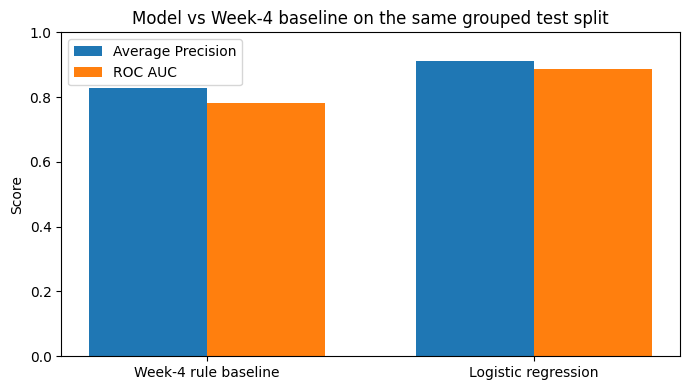

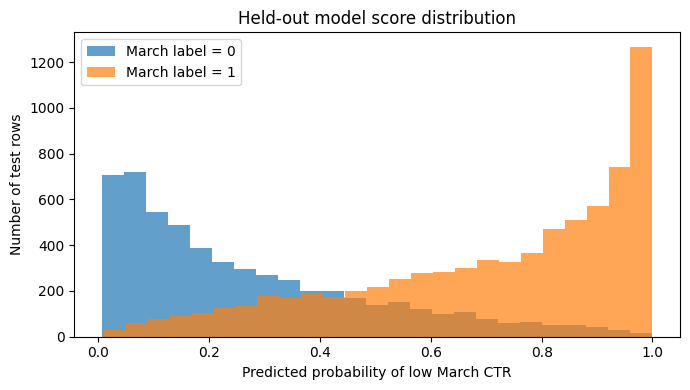

Artifacts:
 - work/outputs/capstone_metrics.csv
 - work/outputs/model_vs_baseline.png
 - work/outputs/model_score_distribution.png
 - work/outputs/capstone_ranked_recommendations.csv


In [13]:

# Paper-ready artifacts.
metrics_path = f"{OUTPUT_DIR}/capstone_metrics.csv"
metrics.to_csv(metrics_path, index=False)

# 1) Metrics chart
plt.figure(figsize=(7, 4))
x = np.arange(len(metrics))
width = 0.36
plt.bar(x - width/2, metrics["average_precision"], width, label="Average Precision")
plt.bar(x + width/2, metrics["roc_auc"], width, label="ROC AUC")
plt.xticks(x, metrics["method"])
plt.ylabel("Score")
plt.title("Model vs Week-4 baseline on the same grouped test split")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
metrics_chart = f"{OUTPUT_DIR}/model_vs_baseline.png"
plt.savefig(metrics_chart, dpi=160)
plt.show()

# 2) Score distribution chart
plt.figure(figsize=(7, 4))
plt.hist(test_df.loc[test_df["low_ctr_mar"] == 0, "model_score"], bins=25, alpha=0.7, label="March label = 0")
plt.hist(test_df.loc[test_df["low_ctr_mar"] == 1, "model_score"], bins=25, alpha=0.7, label="March label = 1")
plt.xlabel("Predicted probability of low March CTR")
plt.ylabel("Number of test rows")
plt.title("Held-out model score distribution")
plt.legend()
plt.tight_layout()
score_chart = f"{OUTPUT_DIR}/model_score_distribution.png"
plt.savefig(score_chart, dpi=160)
plt.show()

print("Artifacts:")
print(" -", metrics_path)
print(" -", metrics_chart)
print(" -", score_chart)
print(" -", f"{OUTPUT_DIR}/capstone_ranked_recommendations.csv")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.